# Optional Lab: Gradient Descent for Logistic Regression
## Goals
In this lab, you will:
- update gradient descent for logistic regression.
- explore gradient descent on a familiar data set

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Dataset

In [2]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

print(f"X_train: {X_train} \n shape: {X_train.shape}")
print(f"y_train: {y_train} \n shape: {y_train.shape}")

X_train: [[0.5 1.5]
 [1.  1. ]
 [1.5 0.5]
 [3.  0.5]
 [2.  2. ]
 [1.  2.5]] 
 shape: (6, 2)
y_train: [0 0 0 1 1 1] 
 shape: (6,)


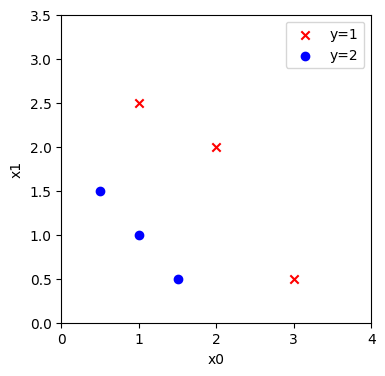

In [8]:
fig, ax = plt.subplots(1,1,figsize=(4,4))

posmask = (y_train.ravel() == 1)
negmask = (y_train.ravel() == 0)

ax.scatter(X_train[posmask, 0], X_train[posmask, 1], marker='x', c='r', label='y=1')
ax.scatter(X_train[negmask, 0], X_train[negmask, 1], marker='o', c='b', label='y=2')

ax.axis([0,4, 0,3.5])
ax.set_xlabel('x0')
ax.set_ylabel('x1')

ax.legend()

plt.show()

## Compute Cost

In [17]:
def sigmoid(z):

    return 1/(1+ np.exp(-z))

In [18]:
def compute_cost(X,y,w,b):

    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)

    cost/=m

    return cost

## Logistic Gradient Descent

Recall the gradient descent algorithm utilizes the gradient calculation:
$$\begin{align*}
&\text{repeat until convergence:} \; \lbrace \\
&  \; \; \;w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1} \\ 
&  \; \; \;  \; \;b = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
&\rbrace
\end{align*}$$

Where each iteration performs simultaneous updates on $w_j$ for all $j$, where
$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2} \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3} 
\end{align*}$$

* m is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target
* For a logistic regression model  
    $z = \mathbf{w} \cdot \mathbf{x} + b$  
    $f_{\mathbf{w},b}(x) = g(z)$  
    where $g(z)$ is the sigmoid function:  
    $g(z) = \frac{1}{1+e^{-z}}$   
    


### Compute Gradient

In [19]:
def compute_gradient(X,y,w,b):

    m,n = X.shape
    
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_Wb_i = sigmoid(z_i)
        err_i = f_Wb_i - y[i]

        for j in range(n):
            dj_dw[j]+=err_i * X[i,j]

        dj_db += err_i

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db


### Gradient Descent Code

In [20]:
import copy
import math

In [22]:
def gradient_descent(X,y,w_in,b_in,alpha,numiter):

    J_hist = []

    w=copy.deepcopy(w_in)
    b=b_in

    for i in range(numiter):
        
        dj_dw, dj_db = compute_gradient(X,y,w,b)

        w -= alpha*dj_dw
        b -= alpha*dj_db

        if i<100000:
            J_hist.append(compute_cost(X,y,w,b))

        if i% math.ceil(numiter / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_hist[-1]}   ")

    return w,b,J_hist


In [23]:
w_tmp = np.zeros_like(X_train[0])
b_tmp = 0
alpha = 0.1
numiter = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alpha, numiter)

print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870456   
Iteration 2000: Cost 0.08460064176930081   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.042907594216820076   
Iteration 5000: Cost 0.034338477298845684   
Iteration 6000: Cost 0.028603798022120097   
Iteration 7000: Cost 0.024501569608793   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   

updated parameters: w:[5.28123029 5.07815608], b:-14.222409982019837


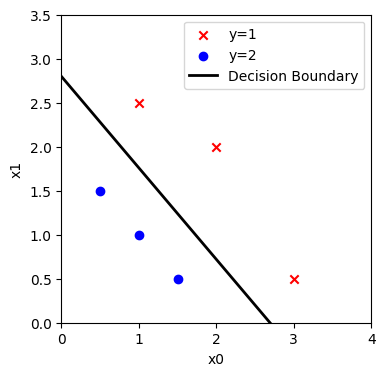

In [34]:
fig, ax = plt.subplots(1,1,figsize=(4,4))

posmask = (y_train.ravel() == 1)
negmask = (y_train.ravel() == 0)

ax.scatter(X_train[posmask, 0], X_train[posmask, 1], marker='x', c='r', label='y=1')
ax.scatter(X_train[negmask, 0], X_train[negmask, 1], marker='o', c='b', label='y=2')

ax.axis([0,4, 0,3.5])

# Decision Boundary
w1 = w_out[0]
w2 = w_out[1]
b = b_out

xmin, xmax = ax.get_xlim() # Get min and max from ax.axis([0,4, 0,3.5])
x1_vals = np.linspace(xmin, xmax, 400) # take 400 points between xmin and xmax

"""
Boundary line equation => w1*x1 + w2*x2 + b = 0
                       => x2 = (- b - w1*x1)/w2 
"""
x2_vals = - (w1 * x1_vals + b)/w2

ax.plot(x1_vals, x2_vals, 'k', linewidth=2, label='Decision Boundary')

ax.set_xlabel('x0')
ax.set_ylabel('x1')

ax.legend()

plt.show()